In [3]:
# Cell 1: Setup & imports

!git clone https://github.com/AutoCS-wyh/Automotive-cyber-threat-intelligence-corpus.git

import os
import random
import numpy as np

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

!pip install -q transformers seqeval torchcrf

from transformers import AutoTokenizer, AutoModel
from seqeval.metrics import f1_score, classification_report



Cloning into 'Automotive-cyber-threat-intelligence-corpus'...
remote: Enumerating objects: 3083, done.
remote: Counting objects: 100% (553/553), done.
remote: Compressing objects: 100% (543/543), done.
remote: Total 3083 (delta 145), reused 61 (delta 8), pack-reused 2530 (from 1)
Receiving objects: 100% (3083/3083), 1.34 MiB | 3.74 MiB/s, done.
Resolving deltas: 100% (467/467), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [4]:
!pip install scikit-learn

In [5]:
!pip install --no-cache-dir git+https://github.com/kmkurn/pytorch-crf.git

  Cloning https://github.com/kmkurn/pytorch-crf.git to /tmp/pip-req-build-tja1lk8d
  Running command git clone --filter=blob:none --quiet https://github.com/kmkurn/pytorch-crf.git /tmp/pip-req-build-tja1lk8d
  Resolved https://github.com/kmkurn/pytorch-crf.git to commit 623e3402d00a2728e99d6e8486010d67c754267b
  Preparing metadata (setup.py) ... done
  Created wheel for pytorch-crf: filename=pytorch_crf-0.7.2-py3-none-any.whl size=6410 sha256=4c94ef127b5cf9733da2c774e1dbb1ee9312e3a9e83e53ad29fe5a084d773d46
  Stored in directory: /tmp/pip-ephem-wheel-cache-d3njqg6e/wheels/a6/3f/e9/a3eb0981973bf404ca2b280c6b6a885a310174436d0adb3445
Successfully built pytorch-crf


In [6]:
from torchcrf import CRF
print("CRF imported successfully!")

CRF imported successfully!


Train file: Automotive-cyber-threat-intelligence-corpus/BIOES/train.txt
Test file: Automotive-cyber-threat-intelligence-corpus/BIOES/test.txt


device(type='cuda')

In [7]:
!find Automotive-cyber-threat-intelligence-corpus -maxdepth 4 -type f


Automotive-cyber-threat-intelligence-corpus/LICENSE
Automotive-cyber-threat-intelligence-corpus/BIOES joint annotation.py
Automotive-cyber-threat-intelligence-corpus/BIOES.txt
Automotive-cyber-threat-intelligence-corpus/read.py
Automotive-cyber-threat-intelligence-corpus/README.md
Automotive-cyber-threat-intelligence-corpus/model/BiLSTM-dynamic-att-LSTM/script/BiLSTM-dynamic-att-LSTM.py
Automotive-cyber-threat-intelligence-corpus/model/BiLSTM-dynamic-att-LSTM/script/preprocess.py
Automotive-cyber-threat-intelligence-corpus/model/BiLSTM-dynamic-att-LSTM/script/utils.py
Automotive-cyber-threat-intelligence-corpus/model/BiLSTM-dynamic-att-LSTM/script/ChunkEvaluator.py
Automotive-cyber-threat-intelligence-corpus/model/BiLSTM-dynamic-att-LSTM/data1/dev.txt
Automotive-cyber-threat-intelligence-corpus/model/BiLSTM-dynamic-att-LSTM/data1/BIOES.txt
Automotive-cyber-threat-intelligence-corpus/model/BiLSTM-dynamic-att-LSTM/data1/train.txt
Automotive-cyber-threat-intelligence-corpus/model/BiLSTM-d

In [8]:
!find Automotive-cyber-threat-intelligence-corpus -maxdepth 5 -type f | grep -i model


Automotive-cyber-threat-intelligence-corpus/model/BiLSTM-dynamic-att-LSTM/script/BiLSTM-dynamic-att-LSTM.py
Automotive-cyber-threat-intelligence-corpus/model/BiLSTM-dynamic-att-LSTM/script/preprocess.py
Automotive-cyber-threat-intelligence-corpus/model/BiLSTM-dynamic-att-LSTM/script/utils.py
Automotive-cyber-threat-intelligence-corpus/model/BiLSTM-dynamic-att-LSTM/script/ChunkEvaluator.py
Automotive-cyber-threat-intelligence-corpus/model/BiLSTM-dynamic-att-LSTM/data1/dev.txt
Automotive-cyber-threat-intelligence-corpus/model/BiLSTM-dynamic-att-LSTM/data1/BIOES.txt
Automotive-cyber-threat-intelligence-corpus/model/BiLSTM-dynamic-att-LSTM/data1/train.txt
Automotive-cyber-threat-intelligence-corpus/model/BiLSTM-dynamic-att-LSTM/data1/tag.dic
Automotive-cyber-threat-intelligence-corpus/model/BERT-BiLSTM-att-CRF/script/bert+bilstm+attention+crf.py
Automotive-cyber-threat-intelligence-corpus/model/BERT-BiLSTM-att-CRF/script/preprocess.py
Automotive-cyber-threat-intelligence-corpus/model/BERT-

In [9]:
!head -20 Automotive-cyber-threat-intelligence-corpus/model/BERT-BiLSTM-att-CRF/data1/train.txt


During brute force: powercycling of the ECU to reduce the brute force time because of sending intervall .	O B_AP_hasImpact_1 O O O O S_Com O O O B_AP E_AP O O O O O O
Exploitation of weak secret keys by cryptoanalysis of the Megamos cipher .	O O B_Vul_M_1 I_Vul_M_1 E_Vul_M_1 O S_AP_targets_1 O O B_Com_targets_2 E_Com_targets_2 O
This kind of objects can cause the Tesla Model X (HW 2.5) to brake suddenly or deviate to a different lane .	O O O O O O O B_Veh_consists-of_2 I_Veh_consists-of_2 E_Veh_consists-of_2 O O O B_Con_hasImpact_2 I_Con_hasImpact_2 I_Con_hasImpact_2 I_Con_hasImpact_2 I_Con_hasImpact_2 I_Con_hasImpact_2 I_Con_hasImpact_2 E_Con_hasImpact_2 O
Theft alert is forwarded to thief .	B_Con_hasImpact_2 I_Con_hasImpact_2 I_Con_hasImpact_2 I_Con_hasImpact_2 I_Con_hasImpact_2 E_Con_hasImpact_2 O
Bleeding the brakes by spoofing a diagnotic CAN message when vehicle is slower than 5 mph .	B_Con_hasImpact_2 I_Con_hasImpact_2 E_Con_hasImpact_2 O S_AP_M_1 O B_Com_targets_2 I_Com_targets

In [10]:
!head -20 Automotive-cyber-threat-intelligence-corpus/model/BERT-BiLSTM-att-CRF/data1/BIOES.txt


Police O
issue O
warning O
after O
keyless B_Con
car I_Con
theft E_Con
in O
Middlesbrough S_Loc
, O
UK S_Loc
. O

The O
theft O
happened O
on O
Saxonfield S_Loc
, O
Colby B_Loc


In [11]:
!head -50 Automotive-cyber-threat-intelligence-corpus/model/BERT-BiLSTM-att-CRF/data1/train.txt


During brute force: powercycling of the ECU to reduce the brute force time because of sending intervall .	O B_AP_hasImpact_1 O O O O S_Com O O O B_AP E_AP O O O O O O
Exploitation of weak secret keys by cryptoanalysis of the Megamos cipher .	O O B_Vul_M_1 I_Vul_M_1 E_Vul_M_1 O S_AP_targets_1 O O B_Com_targets_2 E_Com_targets_2 O
This kind of objects can cause the Tesla Model X (HW 2.5) to brake suddenly or deviate to a different lane .	O O O O O O O B_Veh_consists-of_2 I_Veh_consists-of_2 E_Veh_consists-of_2 O O O B_Con_hasImpact_2 I_Con_hasImpact_2 I_Con_hasImpact_2 I_Con_hasImpact_2 I_Con_hasImpact_2 I_Con_hasImpact_2 I_Con_hasImpact_2 E_Con_hasImpact_2 O
Theft alert is forwarded to thief .	B_Con_hasImpact_2 I_Con_hasImpact_2 I_Con_hasImpact_2 I_Con_hasImpact_2 I_Con_hasImpact_2 E_Con_hasImpact_2 O
Bleeding the brakes by spoofing a diagnotic CAN message when vehicle is slower than 5 mph .	B_Con_hasImpact_2 I_Con_hasImpact_2 E_Con_hasImpact_2 O S_AP_M_1 O B_Com_targets_2 I_Com_targets

In [12]:
# Cell 2: Paths & reproducibility

BASE_DIR = "Automotive-cyber-threat-intelligence-corpus"

TRAIN_PATH = os.path.join(BASE_DIR,
    "model/BERT-BiLSTM-att-CRF/data1/train.txt")
TEST_PATH  = os.path.join(BASE_DIR,
    "model/BERT-BiLSTM-att-CRF/data1/dev.txt")

print("Train file:", TRAIN_PATH)
print("Test file:", TEST_PATH)

# Reproducibility
SEED = 42
import random, torch, numpy as np
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


Train file: Automotive-cyber-threat-intelligence-corpus/model/BERT-BiLSTM-att-CRF/data1/train.txt
Test file: Automotive-cyber-threat-intelligence-corpus/model/BERT-BiLSTM-att-CRF/data1/dev.txt


device(type='cuda')

In [13]:
# Cell 3: Read ACTI joint BIOES data (token-level sequences)

def read_acti_joint(path):
    """
    Reads ACTI train/dev files where each line is:
        token1 token2 ... tokenN \t label1 label2 ... labelN
    Returns: list of (tokens, labels)
    """
    sentences = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            # must split into EXACTLY two parts
            if "\t" not in line:
                continue  # skip malformed lines

            tokens_str, labels_str = line.split("\t")
            tokens = tokens_str.split()
            labels = labels_str.split()

            # validate lengths
            if len(tokens) != len(labels):
                print("Warning: length mismatch:")
                print("Tokens:", tokens)
                print("Labels:", labels)
                continue

            sentences.append((tokens, labels))

    return sentences


train_sentences = read_acti_joint(TRAIN_PATH)
test_sentences  = read_acti_joint(TEST_PATH)

print("Train sentences:", len(train_sentences))
print("Test sentences :", len(test_sentences))

# peek first sample
train_sentences[0]


Train sentences: 2426
Test sentences : 606


(['During',
  'brute',
  'force:',
  'powercycling',
  'of',
  'the',
  'ECU',
  'to',
  'reduce',
  'the',
  'brute',
  'force',
  'time',
  'because',
  'of',
  'sending',
  'intervall',
  '.'],
 ['O',
  'B_AP_hasImpact_1',
  'O',
  'O',
  'O',
  'O',
  'S_Com',
  'O',
  'O',
  'O',
  'B_AP',
  'E_AP',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O'])

In [14]:
# Cell 4: Build label ↔ id mapping (no simplification!)

labels_set = set()

for tokens, labels in train_sentences + test_sentences:
    for lab in labels:
        labels_set.add(lab)

# Convert to sorted list (consistent ordering)
labels_list = sorted(labels_set)

label2id = {lab: i for i, lab in enumerate(labels_list)}
id2label = {i: lab for lab, i in label2id.items()}

num_labels = len(labels_list)

print("Number of labels:", num_labels)
print("Example labels:", labels_list[:15])


Number of labels: 183
Example labels: ['B_AP', 'B_AP_M_1', 'B_AP_M_m', 'B_AP_based-on_1', 'B_AP_hasImpact_1', 'B_AP_located-at_1', 'B_AP_mitigates_2', 'B_AP_targets_1', 'B_AP_uses_1', 'B_AV', 'B_AV_M_2', 'B_AV_based-on_2', 'B_AV_hasInterface_2', 'B_CoA', 'B_CoA_mitigates_1']


In [15]:
# Cell 5: Tokenizer + Dataset class (align labels to BERT subwords)

from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

MAX_LEN = 128

class ActiDataset(torch.utils.data.Dataset):
    def __init__(self, sentences, tokenizer, label2id, max_len=128):
        self.sentences = sentences
        self.tokenizer = tokenizer
        self.label2id = label2id
        self.max_len = max_len

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        tokens, labels = self.sentences[idx]

        # Tokenize words into BERT subwords
        encoding = tokenizer(
            tokens,
            is_split_into_words=True,
            return_offsets_mapping=False,
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )

        input_ids = encoding["input_ids"].squeeze(0)          # (max_len)
        attention_mask = encoding["attention_mask"].squeeze(0)

        # Word ID mapping: each subword gets a word index
        word_ids = encoding.word_ids(batch_index=0)

        # Initialize all sub-tokens with label "O"
        label_ids = []
        for word_id in word_ids:
            if word_id is None:
                label_ids.append(-100)   # ignore special tokens in loss
            else:
                label_ids.append(label2id[labels[word_id]])

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": torch.tensor(label_ids),
            "word_ids": word_ids,
            "tokens": tokens,
            "word_labels": labels
        }


def collate_fn(batch):
    # simple batch stacking (already padded)
    input_ids = torch.stack([item["input_ids"] for item in batch])
    attention_mask = torch.stack([item["attention_mask"] for item in batch])
    labels = torch.stack([item["labels"] for item in batch])

    return {
        "input_ids": input_ids.to(device),
        "attention_mask": attention_mask.to(device),
        "labels": labels.to(device),
        "word_ids_list": [item["word_ids"] for item in batch],
        "tokens_list": [item["tokens"] for item in batch],
        "word_labels_list": [item["word_labels"] for item in batch],
    }


train_dataset = ActiDataset(train_sentences, tokenizer, label2id, max_len=MAX_LEN)
test_dataset  = ActiDataset(test_sentences, tokenizer, label2id, max_len=MAX_LEN)

len(train_dataset), len(test_dataset)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

(2426, 606)

In [16]:
# Cell 6: Define BERT + BiLSTM + Attention + CRF model

from transformers import AutoModel
from torchcrf import CRF

class BertBiLstmAttCrf(nn.Module):
    def __init__(
        self,
        bert_name: str,
        num_labels: int,
        lstm_hidden_size: int = 400,   # BiLSTM -> 800-dim total
        lstm_layers: int = 1,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.bert = AutoModel.from_pretrained(bert_name)
        bert_hidden = self.bert.config.hidden_size  # 768 for bert-base-uncased

        self.lstm = nn.LSTM(
            input_size=bert_hidden,
            hidden_size=lstm_hidden_size,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
        )

        # Simple scalar attention over BiLSTM outputs
        self.att_linear = nn.Linear(lstm_hidden_size * 2, 1)

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(lstm_hidden_size * 2, num_labels)

        self.crf = CRF(num_labels, batch_first=True)

    def forward(self, input_ids, attention_mask, labels=None):
        # 1) BERT contextual embeddings
        bert_outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )
        sequence_output = bert_outputs.last_hidden_state  # (batch, seq, 768)

        # 2) BiLSTM over BERT embeddings
        lstm_out, _ = self.lstm(sequence_output)          # (batch, seq, 2*hidden)

        # 3) Attention scores (mask padding positions)
        att_scores = self.att_linear(lstm_out).squeeze(-1)          # (batch, seq)
        att_scores = att_scores.masked_fill(attention_mask == 0, -1e9)
        att_weights = torch.softmax(att_scores, dim=-1).unsqueeze(-1)  # (batch, seq, 1)

        # 4) Apply attention weighting
        att_out = lstm_out * att_weights                             # (batch, seq, 2*hidden)

        att_out = self.dropout(att_out)
        emissions = self.fc(att_out)                                 # (batch, seq, num_labels)

        # CRF mask: True for real tokens, False for padding
        mask = attention_mask.bool()

        if labels is not None:
            # CRF can’t handle label = -100; replace them with a valid label (e.g. 0)
            labels_clamped = labels.clone()
            labels_clamped[labels_clamped == -100] = 0

            log_likelihood = self.crf(emissions, labels_clamped, mask=mask, reduction='mean')
            loss = -log_likelihood
            return loss
        else:
            # Decode best label sequence
            pred_paths = self.crf.decode(emissions, mask=mask)
            return pred_paths


MODEL_NAME = "bert-base-uncased"

model = BertBiLstmAttCrf(
    bert_name=MODEL_NAME,
    num_labels=num_labels,
    lstm_hidden_size=400,
    lstm_layers=1,
    dropout=0.1,
).to(device)

total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Total parameters: {total_params:.2f}M")


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Total parameters: 113.41M


In [21]:
# Cell 7: DataLoaders & training configuration

from torch.utils.data import DataLoader

BATCH_SIZE = 16        # paper uses 16
EPOCHS = 30            # start small; you can later increase to 20–50+
LR = 5e-5              # close to paper

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)


In [22]:
# Cell 8: Training loop

def train_one_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0.0

    for batch in dataloader:
        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]
        labels = batch["labels"]

        optimizer.zero_grad()
        loss = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels,
        )
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)


for epoch in range(1, EPOCHS + 1):
    avg_loss = train_one_epoch(model, train_loader, optimizer, device)
    print(f"Epoch {epoch}/{EPOCHS} - Train loss: {avg_loss:.4f}")
# Continue training from epoch 11 to 100





Epoch 1/30 - Train loss: 114.8442
Epoch 2/30 - Train loss: 101.4508
Epoch 3/30 - Train loss: 93.5816
Epoch 4/30 - Train loss: 87.2008
Epoch 5/30 - Train loss: 82.1181
Epoch 6/30 - Train loss: 77.4470
Epoch 7/30 - Train loss: 73.7277
Epoch 8/30 - Train loss: 69.9727
Epoch 9/30 - Train loss: 66.8749
Epoch 10/30 - Train loss: 64.1336
Epoch 11/30 - Train loss: 61.5145
Epoch 12/30 - Train loss: 59.4803
Epoch 13/30 - Train loss: 57.0496
Epoch 14/30 - Train loss: 55.0960
Epoch 15/30 - Train loss: 53.2703
Epoch 16/30 - Train loss: 51.6730
Epoch 17/30 - Train loss: 50.0459
Epoch 18/30 - Train loss: 48.6084
Epoch 19/30 - Train loss: 47.3263
Epoch 20/30 - Train loss: 46.0142
Epoch 21/30 - Train loss: 44.8844
Epoch 22/30 - Train loss: 43.5520
Epoch 23/30 - Train loss: 42.5656
Epoch 24/30 - Train loss: 41.6041
Epoch 25/30 - Train loss: 40.5995
Epoch 26/30 - Train loss: 39.7339
Epoch 27/30 - Train loss: 38.6785
Epoch 28/30 - Train loss: 37.9643
Epoch 29/30 - Train loss: 37.4428
Epoch 30/30 - Train l

In [24]:
for epoch in range(31, 51):   # 11 through 100
    avg_loss = train_one_epoch(model, train_loader, optimizer, device)

    # print progress every epoch
    print(f"Epoch {epoch}/50 - Train loss: {avg_loss:.4f}")

    # optional: evaluate every 10 epochs (recommended)


Epoch 31/50 - Train loss: 35.3914
Epoch 32/50 - Train loss: 34.8047
Epoch 33/50 - Train loss: 34.0728
Epoch 34/50 - Train loss: 33.2290
Epoch 35/50 - Train loss: 32.5314
Epoch 36/50 - Train loss: 31.7968
Epoch 37/50 - Train loss: 31.3205
Epoch 38/50 - Train loss: 30.5843
Epoch 39/50 - Train loss: 30.1245
Epoch 40/50 - Train loss: 29.6653
Epoch 41/50 - Train loss: 29.0287
Epoch 42/50 - Train loss: 28.5125
Epoch 43/50 - Train loss: 28.3033
Epoch 44/50 - Train loss: 27.5783
Epoch 45/50 - Train loss: 26.9694
Epoch 46/50 - Train loss: 26.4752
Epoch 47/50 - Train loss: 25.9870
Epoch 48/50 - Train loss: 25.7597
Epoch 49/50 - Train loss: 25.3070
Epoch 50/50 - Train loss: 24.9241


In [25]:
for epoch in range(51, 81):   # 11 through 100
    avg_loss = train_one_epoch(model, train_loader, optimizer, device)

    # print progress every epoch
    print(f"Epoch {epoch}/80 - Train loss: {avg_loss:.4f}")

    # optional: evaluate every 10 epochs (recommended)

Epoch 51/80 - Train loss: 24.5399
Epoch 52/80 - Train loss: 24.4194
Epoch 53/80 - Train loss: 23.8340
Epoch 54/80 - Train loss: 23.2398
Epoch 55/80 - Train loss: 22.8929
Epoch 56/80 - Train loss: 22.6332
Epoch 57/80 - Train loss: 22.2201
Epoch 58/80 - Train loss: 21.9231
Epoch 59/80 - Train loss: 21.5806
Epoch 60/80 - Train loss: 21.2127
Epoch 61/80 - Train loss: 20.7887
Epoch 62/80 - Train loss: 20.3551
Epoch 63/80 - Train loss: 19.9181
Epoch 64/80 - Train loss: 19.6174
Epoch 65/80 - Train loss: 19.2693
Epoch 66/80 - Train loss: 19.2693
Epoch 67/80 - Train loss: 18.7105
Epoch 68/80 - Train loss: 18.3287
Epoch 69/80 - Train loss: 18.1348
Epoch 70/80 - Train loss: 17.7657
Epoch 71/80 - Train loss: 17.2992
Epoch 72/80 - Train loss: 17.0933
Epoch 73/80 - Train loss: 16.8883
Epoch 74/80 - Train loss: 16.5173
Epoch 75/80 - Train loss: 16.2691
Epoch 76/80 - Train loss: 15.8040
Epoch 77/80 - Train loss: 15.5928
Epoch 78/80 - Train loss: 15.4072
Epoch 79/80 - Train loss: 15.0112
Epoch 80/80 - 

In [26]:
for epoch in range(81, 101):   # 11 through 100
    avg_loss = train_one_epoch(model, train_loader, optimizer, device)

    # print progress every epoch
    print(f"Epoch {epoch}/100 - Train loss: {avg_loss:.4f}")

    # optional: evaluate every 10 epochs (recommended)

Epoch 81/100 - Train loss: 14.6064
Epoch 82/100 - Train loss: 14.3819
Epoch 83/100 - Train loss: 14.0263
Epoch 84/100 - Train loss: 13.8607
Epoch 85/100 - Train loss: 13.5478
Epoch 86/100 - Train loss: 13.2565
Epoch 87/100 - Train loss: 13.1244
Epoch 88/100 - Train loss: 12.8085
Epoch 89/100 - Train loss: 12.6824
Epoch 90/100 - Train loss: 12.4769
Epoch 91/100 - Train loss: 12.2408
Epoch 92/100 - Train loss: 12.1030
Epoch 93/100 - Train loss: 11.6949
Epoch 94/100 - Train loss: 11.4437
Epoch 95/100 - Train loss: 11.3138
Epoch 96/100 - Train loss: 11.4546
Epoch 97/100 - Train loss: 11.1998
Epoch 98/100 - Train loss: 11.0603
Epoch 99/100 - Train loss: 10.8772
Epoch 100/100 - Train loss: 10.5498


In [27]:
for epoch in range(101, 126):   # 11 through 100
    avg_loss = train_one_epoch(model, train_loader, optimizer, device)

    # print progress every epoch
    print(f"Epoch {epoch}/125 - Train loss: {avg_loss:.4f}")


Epoch 101/125 - Train loss: 10.4414
Epoch 102/125 - Train loss: 10.3874
Epoch 103/125 - Train loss: 10.0606
Epoch 104/125 - Train loss: 9.8370
Epoch 105/125 - Train loss: 9.8338
Epoch 106/125 - Train loss: 9.6044
Epoch 107/125 - Train loss: 9.3298
Epoch 108/125 - Train loss: 9.2593
Epoch 109/125 - Train loss: 8.9575
Epoch 110/125 - Train loss: 8.8123
Epoch 111/125 - Train loss: 8.6554
Epoch 112/125 - Train loss: 8.5291
Epoch 113/125 - Train loss: 8.4439
Epoch 114/125 - Train loss: 8.8291
Epoch 115/125 - Train loss: 8.5018
Epoch 116/125 - Train loss: 8.2673
Epoch 117/125 - Train loss: 8.1355
Epoch 118/125 - Train loss: 7.8799
Epoch 119/125 - Train loss: 7.6874
Epoch 120/125 - Train loss: 7.5356
Epoch 121/125 - Train loss: 7.3735
Epoch 122/125 - Train loss: 7.3300
Epoch 123/125 - Train loss: 7.2542
Epoch 124/125 - Train loss: 7.3284
Epoch 125/125 - Train loss: 7.0831


In [30]:
def decode_batch_predictions(batch, pred_paths, id2label):
    all_true = []
    all_pred = []

    tokens_list = batch["tokens_list"]          # list of word tokens
    word_labels_list = batch["word_labels_list"]  # true word-level labels
    word_ids_list = batch["word_ids_list"]        # mapping: each subtoken → its word index

    for i in range(len(tokens_list)):
        gold_word_labels = word_labels_list[i]      # true labels per word
        word_ids = word_ids_list[i]                 # list of word indices or None
        pred_seq = pred_paths[i]                    # CRF predicted label IDs per sub-token

        pred_word_labels = []
        last_word_id = None

        # Walk through BERT sub-token predictions
        for pos, w_id in enumerate(word_ids):

            if w_id is None:
                continue  # skip CLS, SEP, PAD

            if w_id != last_word_id:
                # First sub-token of the word → take prediction
                last_word_id = w_id

                if pos < len(pred_seq):
                    lab_id = pred_seq[pos]
                    lab_str = id2label[lab_id]
                    pred_word_labels.append(lab_str)

        # Truncate if mismatch (should not happen often)
        min_len = min(len(gold_word_labels), len(pred_word_labels))
        all_true.append(gold_word_labels[:min_len])
        all_pred.append(pred_word_labels[:min_len])

    return all_true, all_pred


In [40]:
from seqeval.metrics import (
    f1_score,
    precision_score,
    recall_score,
    classification_report
)

def evaluate(model, dataloader, device, id2label):
    model.eval()
    all_true = []
    all_pred = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"]
            attention_mask = batch["attention_mask"]

            pred_paths = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=None,
            )

            batch_true, batch_pred = decode_batch_predictions(batch, pred_paths, id2label)
            all_true.extend(batch_true)
            all_pred.extend(batch_pred)

    overall_precision = precision_score(all_true, all_pred)
    overall_recall = recall_score(all_true, all_pred)
    overall_f1 = f1_score(all_true, all_pred)

    print("=== OVERALL METRICS ===")
    print(f"Precision: {overall_precision:.4f}")
    print(f"Recall:    {overall_recall:.4f}")
    print(f"F1 Score:  {overall_f1:.4f}")

    print("\n=== DETAILED CLASSIFICATION REPORT ===")
    print(classification_report(all_true, all_pred))

    return all_true, all_pred, overall_f1, overall_precision, overall_recall


In [42]:
all_true, all_pred, overall_f1, overall_precision, overall_recall = evaluate(
    model, test_loader, device, id2label
)


=== OVERALL METRICS ===
Precision: 0.4302
Recall:    0.4174
F1 Score:  0.4237

=== DETAILED CLASSIFICATION REPORT ===
                         precision    recall  f1-score   support

                    _AP       0.13      0.14      0.14        14
                _AP_M_1       0.56      0.46      0.50       135
                _AP_M_m       0.00      0.00      0.00         4
        _AP_hasImpact_1       0.40      0.29      0.34        34
          _AP_targets_1       0.45      0.58      0.51        55
             _AP_uses_1       0.00      0.00      0.00         4
                    _AV       0.00      0.00      0.00         3
                _AV_M_2       0.33      0.33      0.33         3
     _AV_hasInterface_2       0.00      0.00      0.00         5
                   _CoA       0.00      0.00      0.00         1
       _CoA_mitigates_1       0.20      0.20      0.20         5
                   _Com       0.43      0.50      0.46       187
               _Com_M_1       0.23  

In [34]:
# Example: extract all labels from train + test
all_labels = []

for tokens, labels in train_sentences:
    all_labels.extend(labels)

for tokens, labels in test_sentences:
    all_labels.extend(labels)


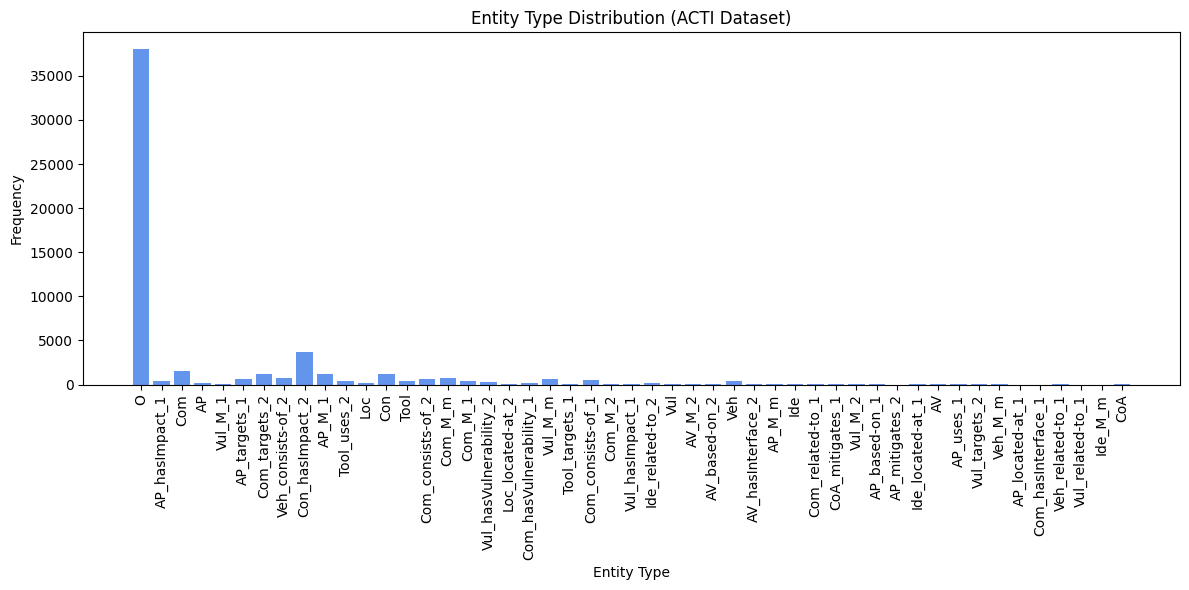

In [35]:
import matplotlib.pyplot as plt
from collections import Counter

# Convert BIOES labels to entity types (strip B_, I_, O, S_, E_)
def simplify(label):
    if label == "O":
        return "O"
    return label.split("_", 1)[1]   # Example: B_AP → AP, B_AP_hasImpact_1 → AP_hasImpact_1

entity_types = [simplify(lbl) for lbl in all_labels]

freq = Counter(entity_types)

plt.figure(figsize=(12,6))
plt.bar(freq.keys(), freq.values(), color='cornflowerblue')
plt.xticks(rotation=90)
plt.title("Entity Type Distribution (ACTI Dataset)")
plt.xlabel("Entity Type")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


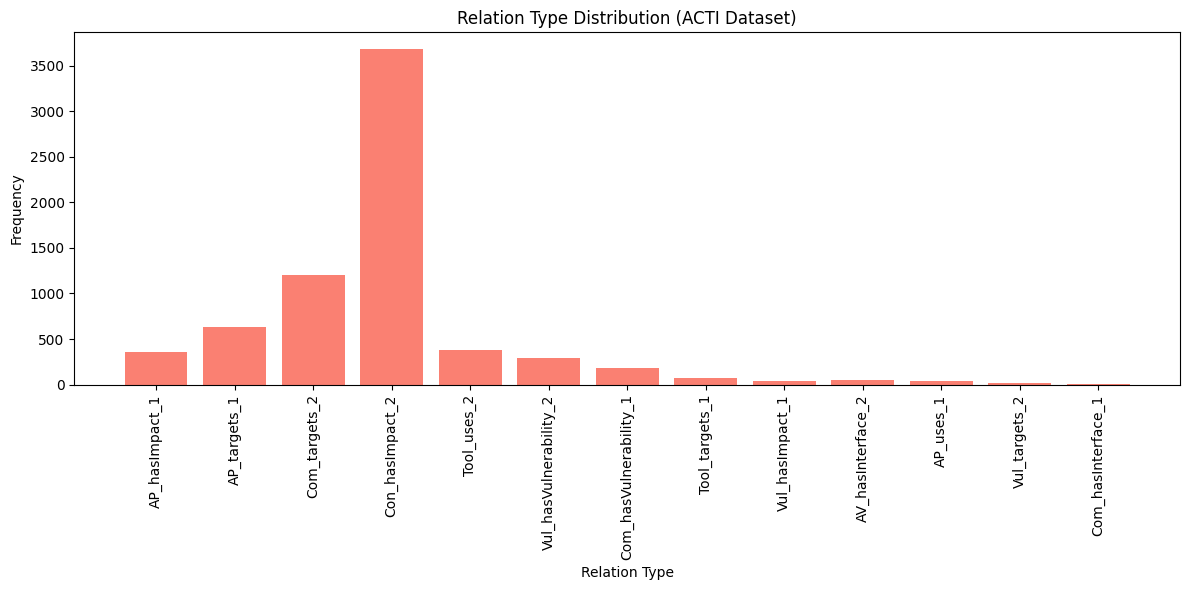

In [36]:
relation_labels = [lbl for lbl in entity_types if "has" in lbl or "targets" in lbl or "uses" in lbl]
rel_freq = Counter(relation_labels)

plt.figure(figsize=(12,6))
plt.bar(rel_freq.keys(), rel_freq.values(), color='salmon')
plt.xticks(rotation=90)
plt.title("Relation Type Distribution (ACTI Dataset)")
plt.xlabel("Relation Type")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


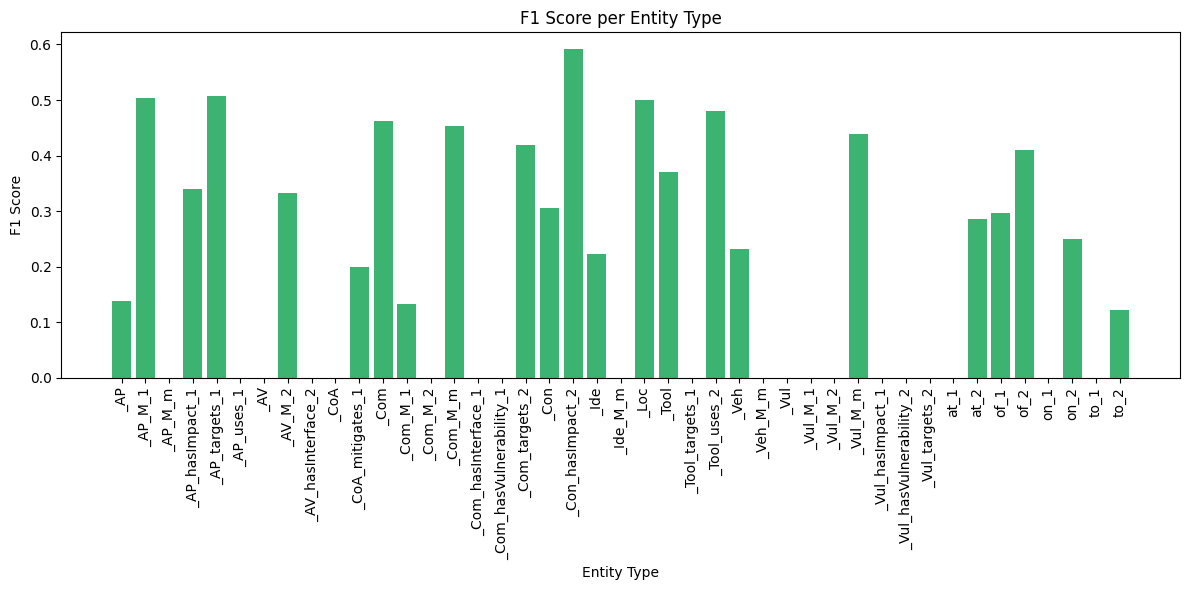

In [43]:
from seqeval.metrics import classification_report
import pandas as pd

# Get classification report as dictionary
report = classification_report(all_true, all_pred, output_dict=True)

# Convert to DataFrame
df = pd.DataFrame(report).transpose()
df_entities = df[~df.index.isin(['micro avg','macro avg','weighted avg'])]

plt.figure(figsize=(12,6))
plt.bar(df_entities.index, df_entities['f1-score'], color='mediumseagreen')
plt.xticks(rotation=90)
plt.title("F1 Score per Entity Type")
plt.ylabel("F1 Score")
plt.xlabel("Entity Type")
plt.tight_layout()
plt.show()


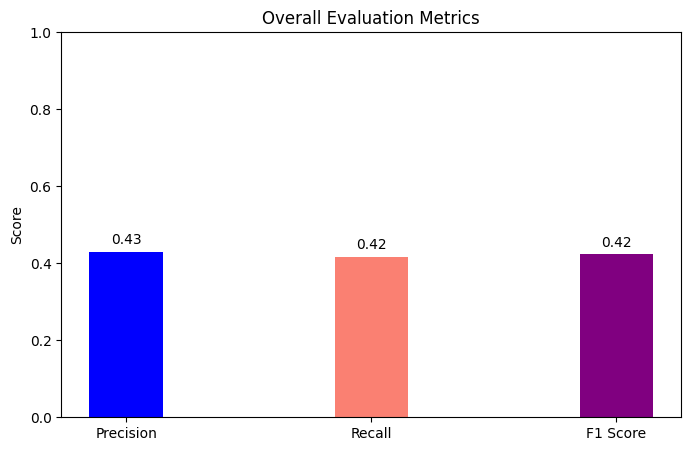

In [8]:
import matplotlib.pyplot as plt

# Your metrics
metrics = ['Precision', 'Recall', 'F1 Score']
values = [0.4302, 0.4174, 0.4237]

# Custom colors (change them as you like)
colors = ['blue', 'salmon', 'purple']  # red, purple, green

# Bar width
bar_width = 0.3   # increase for thicker bars, decrease for thinner

# Create plot
plt.figure(figsize=(8, 5))  # increase width/height of graph
plt.bar(metrics, values, color=colors, width=bar_width)

# Labels and title
plt.ylabel('Score')
plt.title('Overall Evaluation Metrics')
plt.ylim(0, 1)

# Value labels on bars
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=10)

plt.show()
